# 18_归一化方法-对数变换

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们这里，介绍：归一化方法-对数变换\~

**什么是归一化？**

**归一化**的意思是：把原始数据“变一变”，让它的数值**变得更好处理**，比如：

- 把很大的数变小；
- 把不规则的数据变得更“平滑”；
- 让不同特征值更容易比较。

### 对数变换（Log Transformation）

对数变换就是用对数函数，把一个值“压缩”成一个更小的值。

比如，1000 太大不好处理，但我们取它的对数：


$$
\log_{10}(1000) = 3
$$


这个时候我们就把 1000 变成了 3，数值范围一下子就小了，非常适合用在一些数值跨度特别大的数据中。

### 对数变换用来解决什么问题？

举个例子，假设我们有一个数据列：

| 原始数值 |
|-|
| 5 |
| 50 |
| 500 |
| 5000 |
| 50000 |

这些数字差距非常大（跨度几个数量级），在画图或建模时，可能会让模型训练偏向“大的值”，忽略小的值。

我们可以用对数变换把这些值压缩成类似下面这样：

| 原始数值 | 对数变换后 (log10) |
|-|-|
| 5 | 0.698 |
| 50 | 1.699 |
| 500 | 2.699 |
| 5000 | 3.699 |
| 50000 | 4.699 |

从下图看，跨度一下子小了很多！

![原文参考图，当前结果见代码输出](attachments/img_001.png)

## 详细原理

### 数学基础知识：什么是对数？

**对数是“幂”的反操作**。

我们知道：


$$
b^y = x
$$


那就可以写成：


$$
\log_b(x) = y
$$


比如：

$10^3 = 1000$，那么 $\log_{10}(1000) = 3$

假设我们有一组数据 $x_1, x_2, ..., x_n$

对数变换的公式是：


$$
x_i^{\text{new}} = \log_b(x_i)
$$


其中：

- $x_i$：原始值（必须是**正数**，因为对数不能对负数或 0 取值）
- $b$：对数的底数，常见有：
- $\log_{10}$：常用对数（常用于数据归一化）
- $\ln$：自然对数，底数为 e ≈ 2.718（常用于统计建模）

### 为啥能“压缩”数据？

因为对数函数的增长速度很慢：

| x | log10(x) |
|-|-|
| 1 | 0 |
| 10 | 1 |
| 100 | 2 |
| 1000 | 3 |
| 10000 | 4 |

你看，x 每增长 10 倍，log10(x) 只增长 1 个单位！  
这就是「压缩大数」的魔法！

### 防止负数或 0 出错的方法（加1或平移）

有时数据中有 0 或接近 0 的值，直接取对数会报错（因为 $\log(0)$ 是无穷大）。

解决方法：

**加一个常数 c，再取对数**，比如：


$$
x_i^{\text{new}} = \log_b(x_i + c)
$$


常见的设置是：

- $c = 1$：适合小于 1 的正数
- 或使用一个很小的数，比如 $c = 1e{-6}$

## 对数变换的算法流程

一列特征数据 $x_1, x_2, ..., x_n$，我们按照下面步骤处理：

**步骤 1：检查数据合法性**

- 对数不能对 0 或负数操作。
- 所以你要先检查数据中是否有 $x_i \leq 0$。

**步骤 2：加常数（如果有 0 或负数）**

- 如果有问题值，选择一个常数 $c$，比如 $c = 1$。
- 替换所有值：$x_i \gets x_i + c$

**步骤 3：取对数**

- 对每个 $x_i$，计算 $\log(x_i)$，或者 $\log_{10}(x_i)$，或者 $\ln(x_i)$
- 得到新的数据 $x_i^{\text{new}}$

**步骤 4（可选）：缩放到 [0,1] 区间**

如果你需要进一步缩放数据，可以再用**最小-最大归一化**：


$$
x_i^{\text{scaled}} = \frac{x_i^{\text{new}} - \min(x^{\text{new}})}{\max(x^{\text{new}}) - \min(x^{\text{new}})}
$$


这样可以让数据变得适合放入机器学习模型中。

## 完整案例

我们采用一个典型的例子：**收入数据分析**。

个人年收入 或 企业营收 的数据往往是极度不平衡的。

例如：

- 有些人一年收入几千元；
- 而少部分人（比如富豪）年收入数千万；
- 这造成数据呈现「长尾分布」。

这种情况下，如果不进行**归一化处理**，机器学习模型很容易被“富人”影响而忽略普通样本的规律，导致训练不准确。

这时，我们的对数变换」就派上用场了！

我们将：

- 加载一组模拟的年收入数据（代表严重偏态）；
- 对数据进行对数变换；
- 可视化变换前后数据的对比；
- 分析归一化对数据分布的影响；
- 讨论算法的优劣和适用性。

### 代码实现

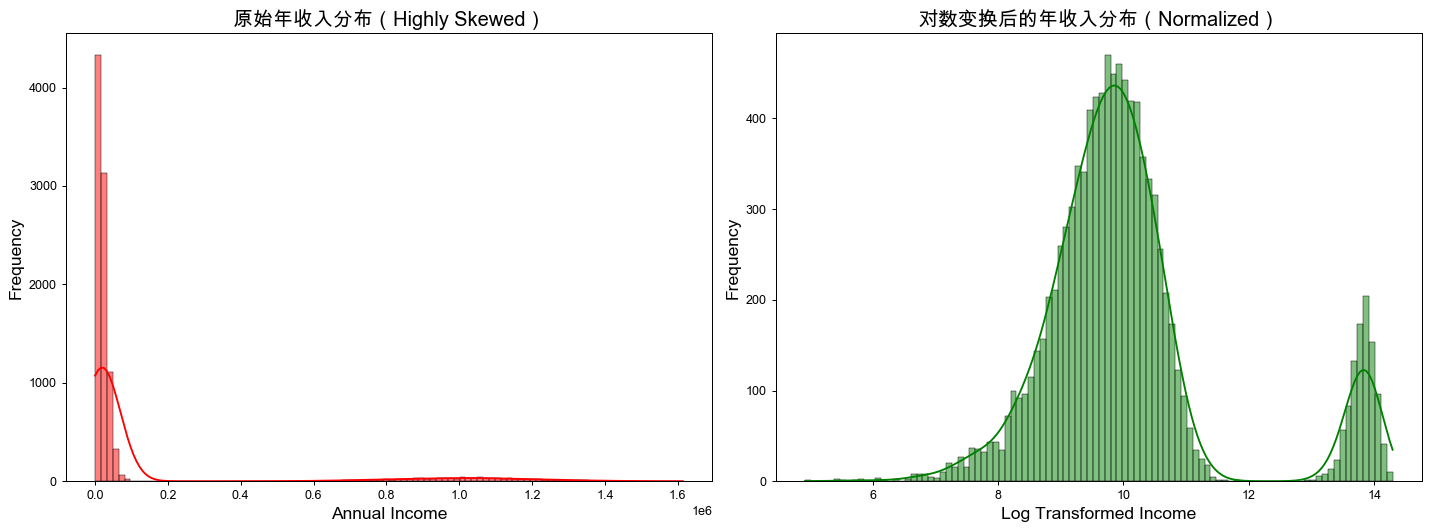

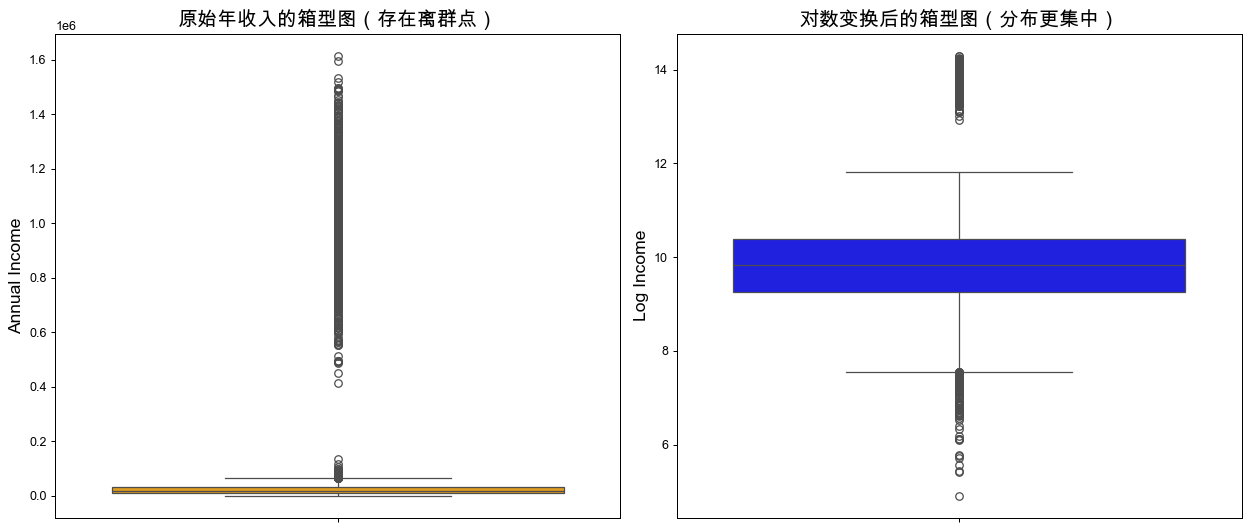

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# 1. 模拟一个高度偏态的年收入数据集（长尾分布）
np.random.seed(42)
low_income = np.random.gamma(shape=2, scale=10000, size=9000)    # 普通人
high_income = np.random.normal(loc=1_000_000, scale=200_000, size=1000)  # 高收入群体
high_income = high_income[high_income > 0]  # 去除负值

income_data = np.concatenate([low_income, high_income])
df = pd.DataFrame({'Annual_Income': income_data})

# 2. 对数变换（添加常数1以避免log(0)）
df['Log_Income'] = np.log1p(df['Annual_Income'])  # 使用log1p等价于log(x+1)

# 3. 可视化变换前后的数据分布（直方图）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 原始分布
sns.histplot(df['Annual_Income'], bins=100, color="red", kde=True, ax=axes[0])
axes[0].set_title("原始年收入分布（Highly Skewed）")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Frequency")

# 对数变换后的分布
sns.histplot(df['Log_Income'], bins=100, color="green", kde=True, ax=axes[1])
axes[1].set_title("对数变换后的年收入分布（Normalized）")
axes[1].set_xlabel("Log Transformed Income")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 4. 可视化箱型图对比
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(y=df['Annual_Income'], color="orange", ax=ax[0])
ax[0].set_title("原始年收入的箱型图（存在离群点）")
ax[0].set_ylabel("Annual Income")

sns.boxplot(y=df['Log_Income'], color="blue", ax=ax[1])
ax[1].set_title("对数变换后的箱型图（分布更集中）")
ax[1].set_ylabel("Log Income")

plt.tight_layout()
plt.show()

### 第1部分：数据模拟（收入严重偏态）

In [3]:
low_income = np.random.gamma(shape=2, scale=10000, size=9000)
high_income = np.random.normal(loc=1_000_000, scale=200_000, size=1000)

- 用**Gamma分布**模拟普通人收入（大多数人年薪1万\~5万）。
- 用**正态分布**模拟富人收入，均值为百万级（高收入群体）。

通过这种设计，我们得到了一个严重偏态的数据集合，非常接近真实社会的收入分布结构。

### 第2部分：对数变换

In [4]:
df['Log_Income'] = np.log1p(df['Annual_Income'])

我们使用了 `np.log1p(x)`，等价于 `log(x + 1)`，这个方法：

- 自动处理了 $x = 0$ 时的问题；
- 保证不会报错（防止对数为负无定义）。

### 第3部分：分布可视化（直方图）

<Axes: xlabel='Annual_Income', ylabel='Count'>

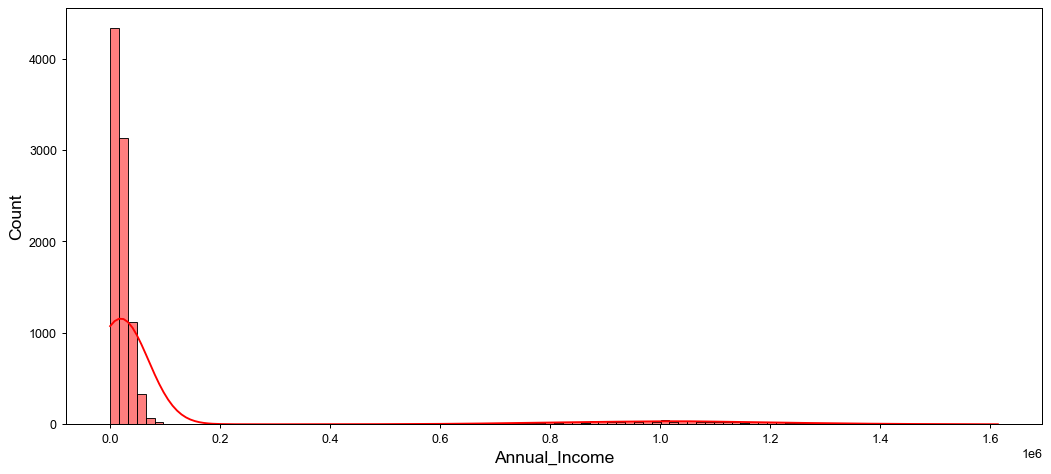

In [5]:
sns.histplot(df['Annual_Income'], bins=100, color="red", kde=True)

- 第一张图展示的是原始数据的**红色直方图**，右边拖得很长；
- 第二张图是**绿色对数变换后**的数据图，整体更集中、近似正态分布；
- 加了 `kde=True`（核密度曲线）方便观察平滑趋势。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

### 第4部分：箱型图比较

<Axes: ylabel='Annual_Income'>

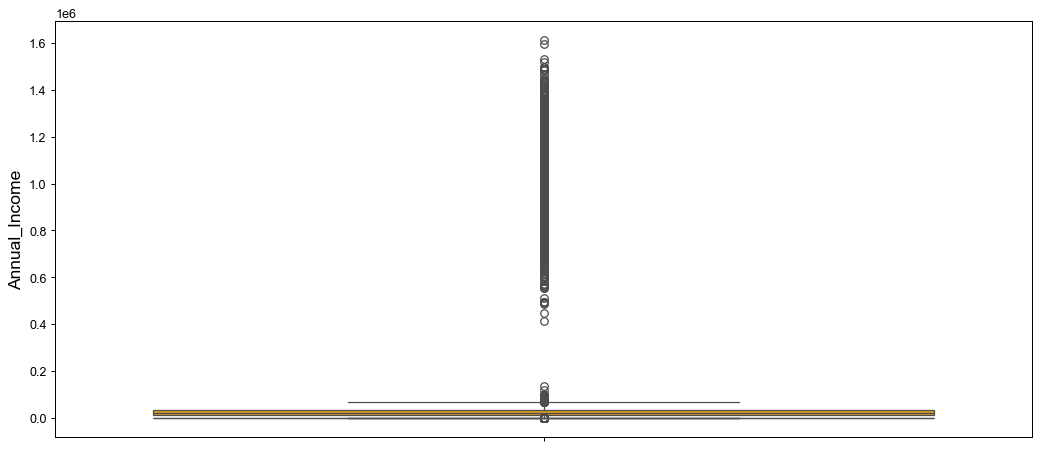

In [6]:
sns.boxplot(y=df['Annual_Income'], color="orange")
sns.boxplot(y=df['Log_Income'], color="blue")

- 箱型图能直观显示**中位数、四分位、异常值**；
- 原始收入数据的箱型图，异常值太多，箱子被拉得极端；
- 对数变换后，异常值减少，数据分布更加集中、对称。

![原文参考图，当前结果见代码输出](attachments/img_003.png)

## 算法分析

### 优点：为什么对数变换很有效？

1. **压缩极端值影响**：原始数据跨度从几千到几百万，差异巨大。对数变换将「1000000」压缩成「13.8」，同时把「10000」压缩成「9.2」，数值更加接近。
2. **降低偏态，近似正态分布**：很多机器学习模型（比如线性回归、逻辑回归、神经网络）对**正态分布**假设敏感。对数变换能让偏态分布更“均匀”。
3. **减少异常值的影响**：原始分布中的离群点（如超高收入者）被严重压缩，不会影响整体趋势建模。
4. **便于建模与可视化**：对数变换后的数据可以用于建模、聚类、预测等环节，模型性能更稳定。

### 缺点与局限性

1. **不能处理负值或0**：对数函数要求输入值必须大于0。如果原始数据中有 0 或负数，必须先加常数或剔除。
2. **丢失“原始尺度”的直观性**：比如收入从1000变成 $\log(1000) \approx 6.9$，用户不容易理解这个“对数值”代表什么。
3. **加常数处理容易引入偏差**：如果加的常数不合理，可能导致模型偏向于较小值。
4. **并非所有偏态分布都适合用 log**：有些非指数增长型的偏态，使用其他变换（如 Box-Cox、Yeo-Johnson）效果可能更好。

## 对数变换适用场景分析

### 当对数变换是优选方案的典型场景：

- 数据呈**长尾分布**（如收入、点击率、访问量、用户存款等）；
- 极端值特别多，需要压缩数据范围；
- 你准备使用的模型对输入分布敏感（例如线性回归）；
- 你不关心原始数值的“量纲”（单位），更关注变化趋势。

### 不适合用对数变换的场景：

- 数据包含**大量0值或负数**，且这些值有真实含义（不能随便加1）；
- 你的模型本身能处理偏态（如树模型：Random Forest、XGBoost）；
- 你要对最终输出做“可解释建模”，原始尺度非常重要（如经济学或医学中的用药剂量）；

## 总结

对数变换是一种非常古老但依然强大的数据归一化手段，它虽然简单，却解决了许多机器学习和统计模型在处理「数值跨度过大」时的核心问题。

在实践中，建议大家：

- 对于明显的「偏态分布」，可以**优先考虑对数变换**；
- 但也要注意变换后的数据可解释性和底层模型的假设；
- 如果对数不适用，可以考虑其他如 Box-Cox、Yeo-Johnson 等高级变换。